## Exploratory Data Analysis

In [54]:
%load_ext autoreload
%autoreload 2
import sys

sys.path.append("..")

import pandas as pd

pd.set_option("display.max_columns", None)

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from scipy.stats import ks_2samp

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import mutual_info_classif, f_classif
from xgboost import XGBClassifier


import warnings
warnings.filterwarnings("ignore")

from src.evaluation import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Load data

In [55]:
x_train = pd.read_csv("../data/x_train.txt", sep=" ")
y_train = pd.read_csv("../data/y_train.txt")

In [56]:
y_train.value_counts()

y
0    2512
1    2488
Name: count, dtype: int64

In [57]:
x_train.isna().values.any()

np.False_

Balanced dataset with no missing values

### Feature Importance

Each additional variable introduces a fixed 200 cost, feature selection became a critical component of the modeling process. Instead of relying on a single importance metric, we performed a broad feature importance analysis using several complementary statistical and machine learning approaches.

The initial analysis served as the foundation for the later feature selection process. To aggregate information from different ranking methods, we introduced an ensemble-based ranking strategy built around the avg_normalized_rank variable. This approach allowed us to identify variables that consistently appeared important across multiple methodologies rather than depending on a single metric.

**Mutual Information**

Measures nonlinear dependency between a feature and the target variable. Unlike correlation-based methods, it can capture more complex relationships between variables and customer conversion behavior.

**ANOVA F-score**

Evaluates whether the mean values of a feature differ significantly between the two target classes. Features with large between-class separation receive higher scores.

**AUC-ROC Feature Score**

Measures how well a single variable separates positive and negative classes independently. Variables with higher discriminatory power achieve better AUC scores.

**Kolmogorov–Smirnov Statistic (KS)**

Compares feature distributions between the two classes. High KS values indicate strong distributional differences between converters and non-converters.

**Logistic Regression with L1 Regularization**

Performs embedded feature selection by shrinking less important coefficients toward zero. This method tends to identify a compact subset of the strongest predictors.

**Random Forest Feature Importance**

Tree-based importance derived from ensemble learning. Captures nonlinear effects and variable interactions that may not be detected by linear methods.


In [58]:
scaler = MinMaxScaler()
x_train_scaled = pd.DataFrame(scaler.fit_transform(x_train), columns=x_train.columns)

y_train = y_train.squeeze()

In [8]:
def calculate_feature_importance(x_train_scaled, y_train):
    # Mutual Information
    mi_scores = mutual_info_classif(x_train_scaled, y_train, random_state=42)
    mi_scores = pd.Series(mi_scores, index=x_train_scaled.columns)
    mi_rank = mi_scores.rank(ascending=False, method="min")

    # ANOVA F-score
    f_scores, p_values = f_classif(x_train_scaled, y_train)
    f_scores = pd.Series(f_scores, index=x_train_scaled.columns)
    f_rank = f_scores.rank(ascending=False, method="min")

    # AUC-ROC Scores
    auc_scores = {}

    for col in x_train_scaled.columns:
        auc = roc_auc_score(y_train, x_train_scaled[col])
        auc = max(auc, 1 - auc)
        auc_scores[col] = auc

    auc_scores = pd.Series(auc_scores)
    auc_rank = auc_scores.rank(ascending=False, method="min")

    # KOLMOGOROV-SMIRNOV (KS) TEST
    ks_scores = {}

    for col in x_train_scaled.columns:
        class_0 = x_train_scaled.loc[y_train == 0, col]
        class_1 = x_train_scaled.loc[y_train == 1, col]

        stat, p_value = ks_2samp(class_0, class_1)
        ks_scores[col] = stat

    ks_scores = pd.Series(ks_scores)
    ks_rank = ks_scores.rank(ascending=False, method="min")

    # Logistic Regression L1
    l1 = LogisticRegression(penalty="l1", solver="saga", max_iter=10_000)

    l1.fit(x_train_scaled, y_train)
    l1_scores = np.abs(l1.coef_[0])
    l1_scores = pd.Series(l1_scores, index=x_train_scaled.columns)
    l1_rank = l1_scores.rank(ascending=False)

    # Tree-based importance
    rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)

    rf.fit(x_train_scaled, y_train)
    rf_scores = pd.Series(rf.feature_importances_, index=x_train_scaled.columns)
    rf_rank = rf_scores.rank(ascending=False)

    # ===================
    # RESULTS TABLE 
    # ===================

    results = pd.DataFrame({
        "feature": x_train_scaled.columns,

        "mutual_info": mi_scores,
        "f_score": f_scores,
        "auc_roc": auc_scores,
        "ks_stat": ks_scores,
        "l1": l1_scores,
        "rf": rf_scores,

        "mi_rank": mi_rank,
        "f_rank": f_rank,
        "auc_roc_rank": auc_rank,
        "ks_stat_rank": ks_rank,
        "l1_rank": l1_rank,
        "rf_rank": rf_rank,

    }).reset_index(drop=True)

    return results


results = calculate_feature_importance(x_train_scaled, y_train)

In [9]:
rank_columns = [
    "mi_rank",
    "f_rank",
    "auc_roc_rank",
    "ks_stat_rank",
    "l1_rank",
    "rf_rank",
]

metric_columns = [
    "mutual_info",
    "f_score",
    "auc_roc",
    "ks_stat",
    "l1",
    "rf",
]

### Ensemble Ranking Based on Feature Ranks

The final feature evaluation was based on the rankings produced by multiple importance methods rather than on the raw importance scores themselves. Since different metrics operate on different scales and measure different properties of the data, direct comparison of raw values would not be meaningful.

For each ranking method stored in `rank_columns`, feature ranks were normalized to the range ([0,1]), where: 0 corresponds to the best-ranked feature, 1 corresponds to the lowest-ranked feature.

The normalized values were then averaged across all ranking methods to create the `avg_normalized_rank` variable. As a result:

* lower `avg_normalized_rank` values indicate features that consistently achieved high positions across multiple methods,
* while higher values correspond to features that were generally considered less important.

Additionally, a voting mechanism (votes_top_k) was introduced to count how many methods selected a given feature among their top-ranked variables.

In [10]:
def calculate_normalized_rank(results, rank_columns):
    n_features = len(results)

    for col in rank_columns:
        results[col + "_norm"] = (results[col] - 1) / (n_features - 1)

    norm_rank_cols = [c + "_norm" for c in rank_columns]
    results["avg_normalized_rank"] = (results[norm_rank_cols].mean(axis=1))

    # lower = better
    results = results.sort_values(by="avg_normalized_rank")

    TOP_K = 100
    results["votes_top_k"] = 0

    for col in rank_columns:
        top_features = results.nsmallest(TOP_K, col)["feature"]
        results.loc[results["feature"].isin(top_features), "votes_top_k"] += 1

    return results

TOP_N = 100

results = calculate_normalized_rank(results, rank_columns)
print("===== Top 20 features by 'avg_normalized_rank' =====")
display(results.head(n=20))
results.to_csv(f"../outputs/feature_importance_ranking.csv", index=False)

===== Top 20 features by 'avg_normalized_rank' =====


,feature,mutual_info,f_score,auc_roc,ks_stat,l1,rf,mi_rank,f_rank,auc_roc_rank,ks_stat_rank,l1_rank,rf_rank,mi_rank_norm,f_rank_norm,auc_roc_rank_norm,ks_stat_rank_norm,l1_rank_norm,rf_rank_norm,avg_normalized_rank,votes_top_k
389,V390,0.008511,65.771559,0.555207,0.081085,3.602979,0.005130,76.0,1.0,7.0,16.0,1.0,12.0,0.150301,0.000000,0.012024,0.030060,0.000000,0.022044,0.035738,6
308,V309,0.009498,43.722840,0.553451,0.091623,0.837995,0.002826,64.0,10.0,9.0,9.0,7.0,24.0,0.126253,0.018036,0.016032,0.016032,0.012024,0.046092,0.039078,6
344,V345,0.009262,44.907550,0.547913,0.085407,2.104829,0.003451,68.0,8.0,13.0,13.0,3.0,22.0,0.134269,0.014028,0.024048,0.024048,0.004008,0.042084,0.040414,6
198,V199,0.008195,50.191733,0.551746,0.083627,2.346162,0.004915,79.0,7.0,11.0,14.0,2.0,15.0,0.156313,0.012024,0.020040,0.026052,0.002004,0.028056,0.040748,6
31,V32,0.006444,53.937593,0.558361,0.087775,1.197691,0.004429,108.0,4.0,3.0,10.0,4.5,18.0,0.214429,0.006012,0.004008,0.018036,0.007014,0.034068,0.047261,5
174,V175,0.006444,53.937593,0.558361,0.087775,1.197691,0.003743,108.0,4.0,3.0,10.0,4.5,20.0,0.214429,0.006012,0.004008,0.018036,0.007014,0.038076,0.047929,5
463,V464,0.012494,7.930038,0.524538,0.053097,0.567183,0.002191,32.0,22.0,21.0,29.0,8.0,41.0,0.062124,0.042084,0.040080,0.056112,0.014028,0.080160,0.049098,6
264,V265,0.015911,37.632162,0.552773,0.107549,0.153174,0.005396,16.0,12.0,10.0,4.0,168.0,10.0,0.030060,0.022044,0.018036,0.006012,0.334669,0.018036,0.071476,5
255,V256,0.009380,5.962121,0.516043,0.043255,0.437414,0.002109,65.0,26.0,39.0,37.0,16.0,61.0,0.128257,0.050100,0.076152,0.072144,0.030060,0.120240,0.079492,6
376,V377,0.013432,3.871382,0.515868,0.043800,0.215084,0.002410,23.0,37.0,40.0,36.0,92.0,28.0,0.044088,0.072144,0.078156,0.070140,0.182365,0.054108,0.083500,6


---

### Interpretation of Feature Importance Rankings

The comparison of rankings across different importance metrics shows that individual methods often prioritize different variables. Only a relatively small number of features consistently appear within the top-ranked subset across all methods.

This observation suggests that no single metric fully captures the predictive structure of the dataset. Therefore, an ensemble-based ranking approach may be more effective because it combines information coming from multiple independent evaluation strategies.

The L1-regularized logistic regression appears to select a compact group of highly informative variables. Interestingly, many of these variables are also identified by other methods, which strengthens confidence in their predictive value.

Mutual Information behaves differently from most remaining metrics. Because it captures nonlinear dependencies, it often promotes features that are not necessarily ranked highly by linear or distribution-based approaches.

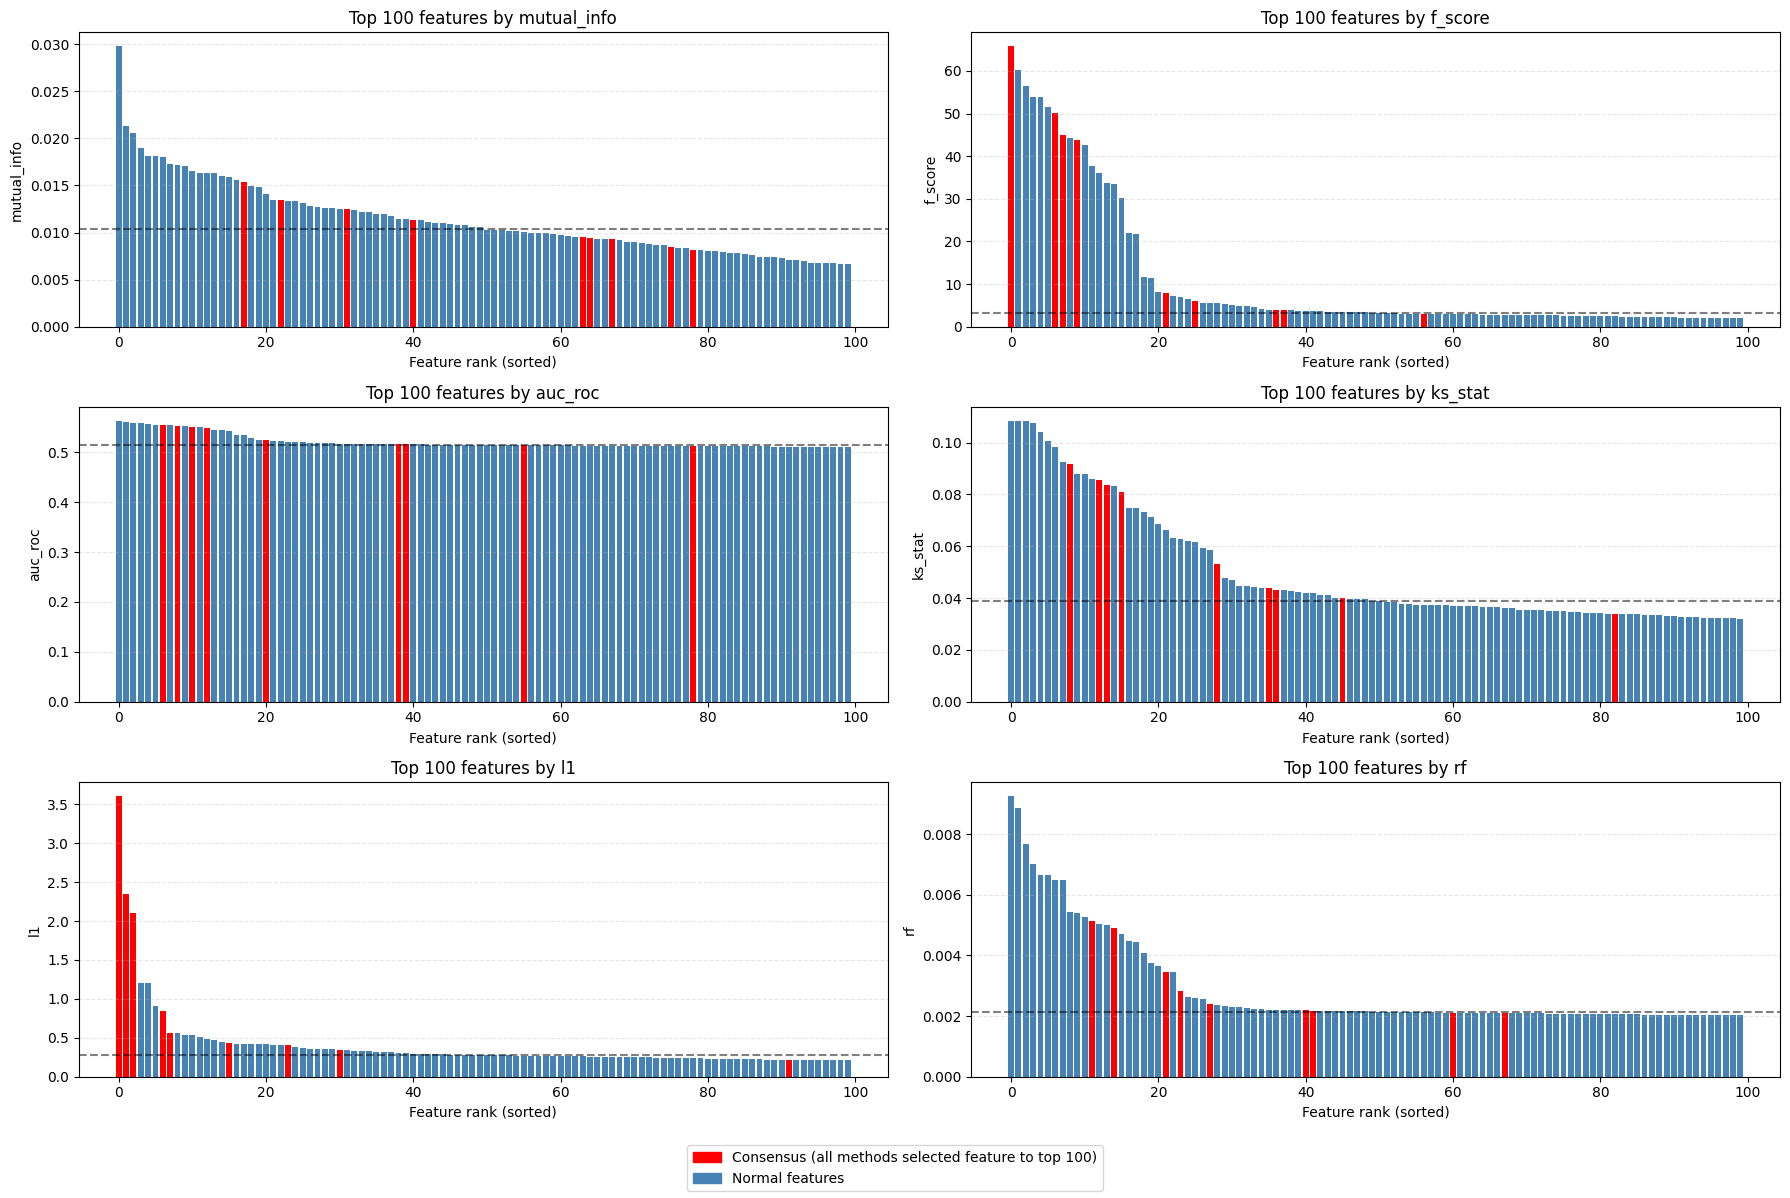

In [11]:
metrics = metric_columns
consensus_mask = results["votes_top_k"] == len(metrics)

n_cols = 2
n_rows = int(np.ceil(len(metrics) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(metrics):
    df = results.sort_values(by=col, ascending=False).head(TOP_N)
    colors = np.where(df["votes_top_k"] == len(metrics), "red", "steelblue")

    axes[i].bar(range(len(df)), df[col], color=colors)

    axes[i].set_title(f"Top {TOP_N} features by {col}")
    axes[i].set_xlabel("Feature rank (sorted)")
    axes[i].set_ylabel(col)

    axes[i].axhline(df[col].median(), linestyle="--", color="black", alpha=0.5)
    axes[i].grid(True, linestyle="--", alpha=0.3, axis="y")

red_patch = mpatches.Patch(color='red', label=f'Consensus (all methods selected feature to top {TOP_N})')
blue_patch = mpatches.Patch(color='steelblue', label='Normal features')

fig.legend(
    handles=[red_patch, blue_patch],
    loc='lower center'
)

plt.tight_layout(rect=(0, 0.05, 1, 1))
plt.show()

In the later stages of model development, we do not rely exclusively on the created ensemble ranking. Instead, the rankings generated in this section are treated as complementary sources of information. During model evaluation, we experiment with feature subsets derived from different ranking methods in order to assess how individual selection strategies influence predictive performance, model stability, and overall campaign profitability.

---

### Distribution Analysis of Top Features

Density analysis of the highest-ranked variables revealed that even the most important features do not strongly separate the two target classes individually. In most cases, the distributions for positive and negative classes substantially overlap.

This suggests that the predictive signal is relatively weak at the single-feature level and that successful classification likely depends on combining information from multiple variables simultaneously rather than relying on strong individual predictors.

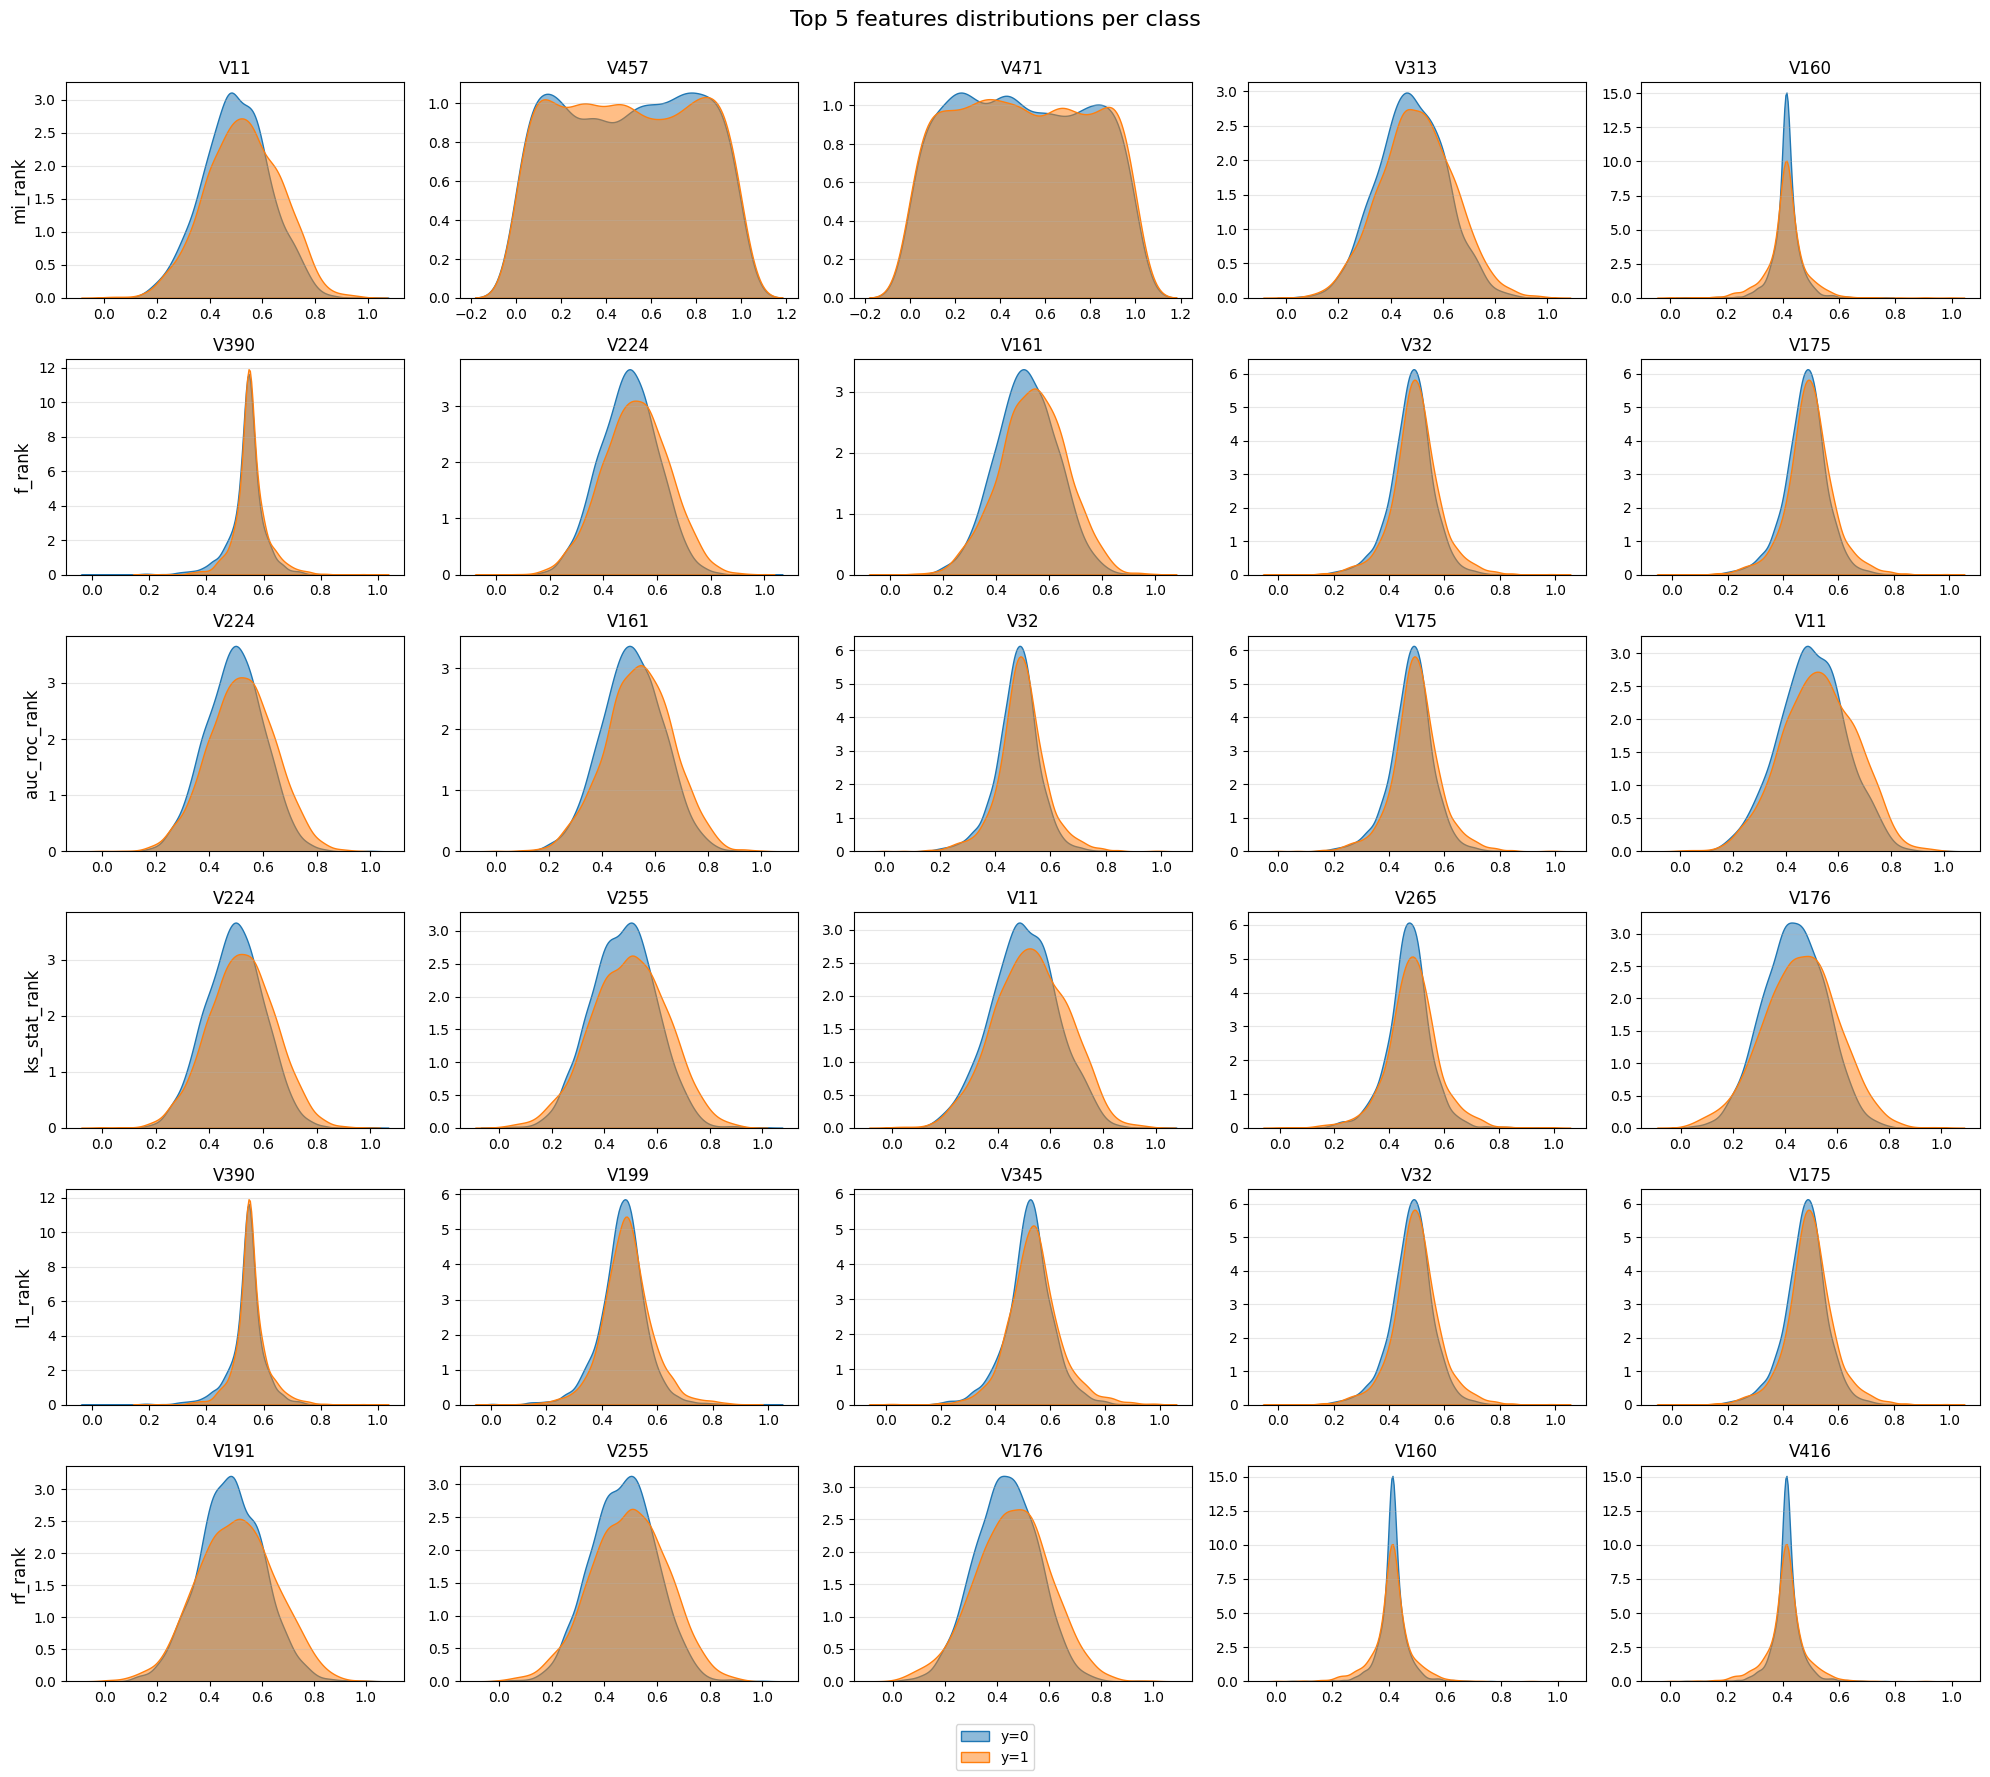

In [12]:
TOP_K = 5

n_rows = len(rank_columns)
n_cols = TOP_K

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))

for row_idx, rank_col in enumerate(rank_columns):

    top_features = (results.sort_values(rank_col).head(TOP_K)["feature"].values)

    for col_idx, feature in enumerate(top_features):

        ax = axes[row_idx, col_idx]

        # class 0
        sns.kdeplot(
            x=x_train_scaled.loc[y_train == 0, feature],
            ax=ax,
            label="y=0",
            fill=True,
            alpha=0.5,
        )

        # class 1
        sns.kdeplot(
            x=x_train_scaled.loc[y_train == 1, feature],
            ax=ax,
            label="y=1",
            fill=True,
            alpha=0.5
        )

        ax.set_title(f"{feature}")

        if col_idx == 0:
            ax.set_ylabel(rank_col, fontsize=12)
        else:
            ax.set_ylabel("")

        ax.set_xlabel("")
        ax.grid(True, alpha=0.3, axis="y")

        if not (row_idx == 0 and col_idx == 0):
            legend = ax.get_legend()
            if legend is not None:
                legend.remove()

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center")

plt.suptitle("Top 5 features distributions per class", fontsize=16)
plt.tight_layout(rect=(0, 0.03, 1, 0.98))
plt.show()

---

### Feature correlation with Target

(51, 51)


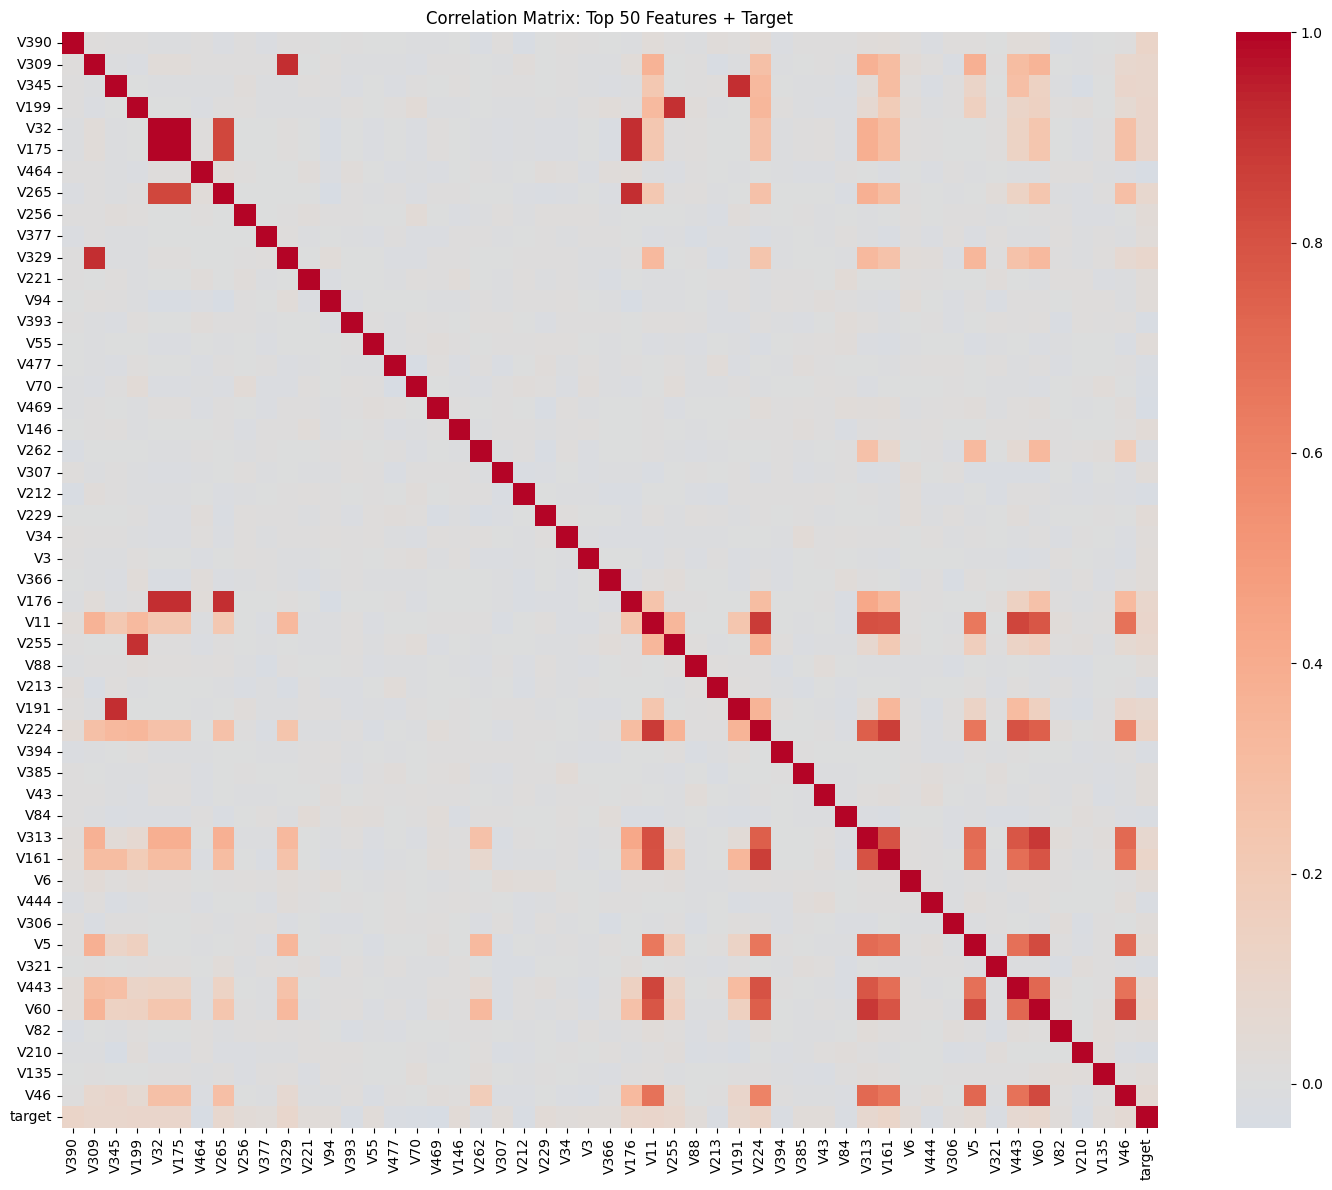

In [13]:
feature_importance_df = pd.read_csv("../outputs/feature_importance_ranking.csv")

top_100_features = (
    feature_importance_df
    .sort_values("avg_normalized_rank")
    .head(50)["feature"]
    .tolist()
)

X_top100 = x_train_scaled[top_100_features]

corr_df = X_top100.copy()
corr_df["target"] = y_train.values

corr_matrix = corr_df.corr(method="pearson")

print(corr_matrix.shape)

plt.figure(figsize=(16, 12))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    square=True,
)

plt.title("Correlation Matrix: Top 50 Features + Target")
plt.tight_layout()
plt.show()

In [59]:
results = pd.read_csv("../outputs/feature_importance_ranking.csv")
feature_names = results["feature"].values

X = x_train_scaled[feature_names]

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

xgb.fit(X, y_train)

xgb_scores = pd.Series(
    xgb.feature_importances_,
    index=feature_names
)

xgb_rank = xgb_scores.rank(ascending=False, method="min")

results = results.copy()

results["xgb"] = results["feature"].map(xgb_scores)
results["xgb_rank"] = results["feature"].map(xgb_rank)

rank_columns = [
    "mi_rank",
    "f_rank",
    "auc_roc_rank",
    "ks_stat_rank",
    "l1_rank",
    "rf_rank",
    "xgb_rank",
]

def calculate_normalized_rank(results, rank_columns):
    n_features = len(results)

    for col in rank_columns:
        results[col + "_norm"] = (results[col] - 1) / (n_features - 1)

    norm_cols = [c + "_norm" for c in rank_columns]
    results["avg_normalized_rank"] = results[norm_cols].mean(axis=1)

    results = results.sort_values(by="avg_normalized_rank")

    TOP_K = 100
    results["votes_top_k"] = 0

    for col in rank_columns:
        top_features = results.nsmallest(TOP_K, col)["feature"]
        results.loc[results["feature"].isin(top_features), "votes_top_k"] += 1

    return results

results = calculate_normalized_rank(results, rank_columns)

results.to_csv(
    "../outputs/feature_importance_ranking_xgb.csv",
    index=False
)

print("Saved: feature_importance_ranking_xgb.csv")

Saved: feature_importance_ranking_xgb.csv
